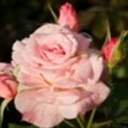

In [2]:
import numpy as np
import torch
from PIL import Image

im = Image.open("rose_crop.jpg")
im_small = im.resize((128, 128))
im_small

In [4]:


class PositionalEmbedding(torch.nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.freq = torch.exp(torch.arange(0, embed_dim, 2).float() / 2)

    def forward(self, x):
        # x.shape  B x 2
        x = x[..., None, :] * self.freq[..., None].to(x.device)
        return torch.cat([torch.sin(x), torch.cos(x)], dim=-1).view(*x.shape[:-2], -1)


# f, ax = plt.subplots(3, 3, figsize=(5, 5))

# pe = PositionalEmbedding(8)
# e = pe(torch.linspace(-1, 1, 100)[:, None])
# for i in range(8):
#     ax[i // 3, i % 3].plot(e[:, i].numpy())

0.3050958514213562
0.05525858327746391
0.031439974904060364
0.025779103860259056
0.02001693844795227
0.019449692219495773
0.016157768666744232
0.014525706879794598
0.014355277642607689
0.015020666643977165
0.012234225869178772
0.012656060978770256
0.01289273239672184
0.01212768629193306
0.012641030363738537
0.01244947500526905
0.009911781176924706
0.010248346254229546
0.011298127472400665
0.010402388870716095
0.009005077183246613
0.009137675166130066
0.010103157721459866
0.009988147765398026
0.00905915629118681
0.008291753008961678
0.009982737712562084
0.00814845785498619
0.0080154063180089
0.008274039253592491
0.007363037206232548
0.009052865207195282
0.007231419440358877
0.008334559388458729
0.007376573979854584
0.007652244530618191
0.006709481589496136
0.009217066690325737
0.007186185568571091
0.008168873377144337
0.007000449113547802
0.007357626687735319
0.00755177391692996
0.007086760830134153
0.006496045738458633
0.007374779786914587
0.006790343206375837
0.008265296928584576
0.00

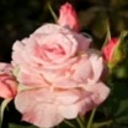

In [5]:


class Rose(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = PositionalEmbedding(12)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(24, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 3),
        )

    def forward(self, x):
        return self.net(self.enc(x))


rose_tensor = torch.as_tensor(np.array(im_small), dtype=torch.float32) / 255.0 - 0.5
position = torch.stack(torch.meshgrid(torch.linspace(-1, 1, 128), torch.linspace(-1, 1, 128)), dim=-1)


net = Rose()

rose_tensor = rose_tensor.cuda()
position = position.cuda()
net = net.cuda()

optim = torch.optim.Adam(net.parameters(), lr=1e-3)
for it in range(5000):
    optim.zero_grad()
    loss = abs(net(position) - rose_tensor).mean()
    if it % 100 == 0:
        print(float(loss))
    loss.backward()
    optim.step()

Image.fromarray(((net(position) + 0.5).clamp(0, 1) * 255).cpu().to(torch.uint8).numpy())

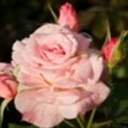

In [6]:
im_small

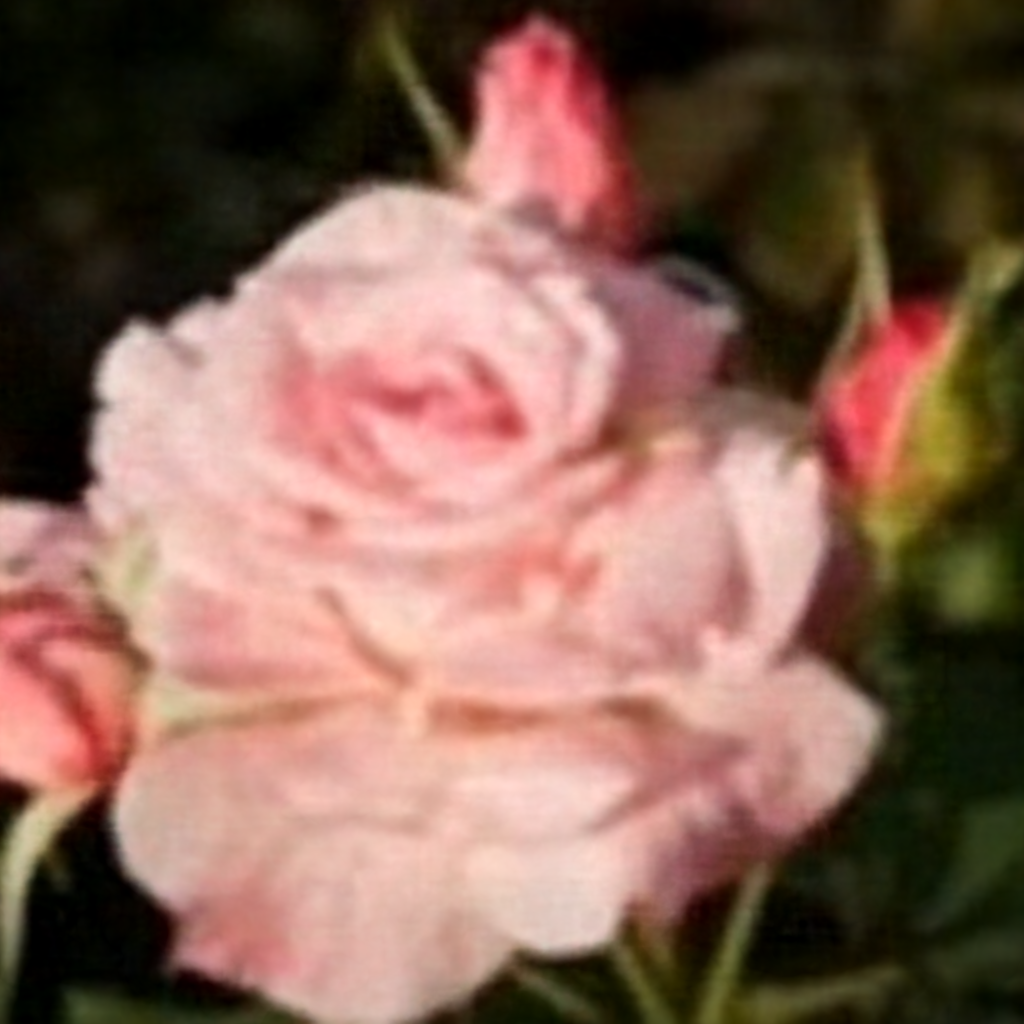

In [7]:
position_hires = torch.stack(torch.meshgrid(torch.linspace(-1, 1, 1024), torch.linspace(-1, 1, 1024)), dim=-1).cuda()

Image.fromarray(((net(position_hires) + 0.5).clamp(0, 1) * 255).cpu().to(torch.uint8).numpy())